Why MLPs Fail on Images

In [1]:
import numpy as np

image_height = 64
image_width = 64
channels = 3

total_input_features = image_height * image_width * channels
mlp_hidden_neurons = 512

weights_mlp = np.random.randn(total_input_features, mlp_hidden_neurons)

print("Image dimensions: 64x64x3")
print("Total input features after flattening:", total_input_features)
print("Shape of MLP Layer 1 Weights Matrix:", weights_mlp.shape)
print("Total parameters in just the first hidden layer:", weights_mlp.size)


Image dimensions: 64x64x3
Total input features after flattening: 12288
Shape of MLP Layer 1 Weights Matrix: (12288, 512)
Total parameters in just the first hidden layer: 6291456


The Core Convolution Engine (Filters and Feature Maps)

In [7]:
import numpy as np

# 1D array banakar use 6x6 matrix mein badal diya taaki rendering error na aaye
image = np.array([10, 10, 10, 0, 0, 0, 10, 10, 10, 0, 0, 0, 10, 10, 10, 0, 0, 0, 10, 10, 10, 0, 0, 0, 10, 10, 10, 0, 0, 0, 10, 10, 10, 0, 0, 0]).reshape(6, 6)

# Filter ko bhi flatten karke 3x3 mein badal diya
filter_vertical = np.array([1, 0, -1, 1, 0, -1, 1, 0, -1]).reshape(3, 3)

img_h, img_w = image.shape
f_h, f_w = filter_vertical.shape

out_h = img_h - f_h + 1
out_w = img_w - f_w + 1
feature_map = np.zeros((out_h, out_w))

for r in range(out_h):
    for c in range(out_w):
        region = image[r : r + f_h, c : c + f_w]
        feature_map[r, c] = np.sum(region * filter_vertical)

print("Original Image Matrix:\n", image)
print("\nVertical Edge Detection Filter:\n", filter_vertical)
print("\nGenerated Feature Map (Output):\n", feature_map)


Original Image Matrix:
 [[10 10 10  0  0  0]
 [10 10 10  0  0  0]
 [10 10 10  0  0  0]
 [10 10 10  0  0  0]
 [10 10 10  0  0  0]
 [10 10 10  0  0  0]]

Vertical Edge Detection Filter:
 [[ 1  0 -1]
 [ 1  0 -1]
 [ 1  0 -1]]

Generated Feature Map (Output):
 [[ 0. 30. 30.  0.]
 [ 0. 30. 30.  0.]
 [ 0. 30. 30.  0.]
 [ 0. 30. 30.  0.]]


In [8]:
import numpy as np

# 1D array banakar use 4x4 matrix mein badal diya
image = np.array([5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5]).reshape(4, 4)

pad_width = 1

# Border padding logic execution using NumPy engine
padded_image = np.pad(image, pad_width=pad_width, mode='constant', constant_values=0)

print("Original 4x4 Image Matrix:\n", image)
print(f"\nPadded Image Matrix (With pad_width={pad_width}):\n", padded_image)
print("\nShape changes from:", image.shape, "to:", padded_image.shape)


Original 4x4 Image Matrix:
 [[5 5 5 5]
 [5 5 5 5]
 [5 5 5 5]
 [5 5 5 5]]

Padded Image Matrix (With pad_width=1):
 [[0 0 0 0 0 0]
 [0 5 5 5 5 0]
 [0 5 5 5 5 0]
 [0 5 5 5 5 0]
 [0 5 5 5 5 0]
 [0 0 0 0 0 0]]

Shape changes from: (4, 4) to: (6, 6)


 Strided Convolutions From Scratch

In [9]:
import numpy as np

# 5x5 input image using reshaped array to avoid formatting errors
image = np.array([
    1, 2, 3, 0, 1,
    0, 1, 2, 4, 1,
    1, 0, 1, 1, 0,
    2, 3, 0, 1, 2,
    0, 2, 1, 0, 1
]).reshape(5, 5)

# 3x3 Filter matrix
filter_kernel = np.array([
    1, 0, -1,
    1, 0, -1,
    1, 0, -1
]).reshape(3, 3)

stride = 2
img_h, img_w = image.shape
f_h, f_w = filter_kernel.shape

# Output dimension formula: ((N - F) / Stride) + 1
out_h = int((img_h - f_h) / stride) + 1
out_w = int((img_w - f_w) / stride) + 1
feature_map = np.zeros((out_h, out_w))

for r in range(0, img_h - f_h + 1, stride):
    for c in range(0, img_w - f_w + 1, stride):
        region = image[r : r + f_h, c : c + f_w]

        # Calculate indices for output matrix mapping
        out_r = r // stride
        out_c = c // stride
        feature_map[out_r, out_c] = np.sum(region * filter_kernel)

print("Original 5x5 Image Matrix:\n", image)
print("\nGenerated Feature Map with Stride 2:\n", feature_map)
print("\nFinal Output Shape:", feature_map.shape)


Original 5x5 Image Matrix:
 [[1 2 3 0 1]
 [0 1 2 4 1]
 [1 0 1 1 0]
 [2 3 0 1 2]
 [0 2 1 0 1]]

Generated Feature Map with Stride 2:
 [[-4.  4.]
 [ 1. -1.]]

Final Output Shape: (2, 2)


Pooling Layers From Scratch

In [10]:
import numpy as np

feature_map = np.array([
    12, 20, 30, 0,
    8,  12, 2,  0,
    34, 70, 37, 4,
    112, 10, 25, 12
]).reshape(4, 4)

pool_size = 2
stride = 2

img_h, img_w = feature_map.shape
out_h = int((img_h - pool_size) / stride) + 1
out_w = int((img_w - pool_size) / stride) + 1

max_pool_out = np.zeros((out_h, out_w))
avg_pool_out = np.zeros((out_h, out_w))

for r in range(0, img_h, stride):
    for c in range(0, img_w, stride):
        region = feature_map[r : r + pool_size, c : c + pool_size]
        out_r = r // stride
        out_c = c // stride

        max_pool_out[out_r, out_c] = np.max(region)
        avg_pool_out[out_r, out_c] = np.mean(region)

print("Input Feature Map (4x4):\n", feature_map)
print("\nMax Pooling Output (2x2):\n", max_pool_out)
print("\nAverage Pooling Output (2x2):\n", avg_pool_out)


Input Feature Map (4x4):
 [[ 12  20  30   0]
 [  8  12   2   0]
 [ 34  70  37   4]
 [112  10  25  12]]

Max Pooling Output (2x2):
 [[ 20.  30.]
 [112.  37.]]

Average Pooling Output (2x2):
 [[13.   8. ]
 [56.5 19.5]]


A Complete CNN Architecture (Forward Pass Flow) From Scratch

In [13]:
import numpy as np

np.random.seed(42)

# Generate bright left pixels (10) and dark right pixels (0) automatically using repeat logic
row_pattern = np.repeat([10.0, 10.0, 0.0, 0.0, 0.0], 5)
image = row_pattern.reshape(5, 5)

# Generate a vertical filter [1, 0, -1] repeated across columns automatically
filter_pattern = np.tile([1.0, 0.0, -1.0], 3)
conv_filter = filter_pattern.reshape(3, 3)

dense_W = np.random.randn(4, 2) * 0.1
dense_b = np.zeros((1, 2))

# 1. CONVOLUTION LAYER
img_h, img_w = image.shape
f_h, f_w = conv_filter.shape
out_h, out_w = img_h - f_h + 1, img_w - f_w + 1
conv_output = np.zeros((out_h, out_w))

for r in range(out_h):
    for c in range(out_w):
        region = image[r : r + f_h, c : c + f_w]
        conv_output[r, c] = np.sum(region * conv_filter)

# 2. MAX POOLING LAYER (2x2 filter, stride 1)
pool_size, pool_stride = 2, 1
p_out_h = int((out_h - pool_size) / pool_stride) + 1
p_out_w = int((out_w - pool_size) / pool_stride) + 1
pooling_output = np.zeros((p_out_h, p_out_w))

for r in range(0, out_h - pool_size + 1, pool_stride):
    for c in range(0, out_w - pool_size + 1, pool_stride):
        region = conv_output[r : r + pool_size, c : c + pool_size]
        pooling_output[r // pool_stride, c // pool_stride] = np.max(region)

# 3. FLATTEN LAYER
flattened_features = pooling_output.flatten().reshape(1, -1)

# 4. DENSE (FULLY CONNECTED) LAYER
dense_z = np.dot(flattened_features, dense_W) + dense_b
final_predictions = 1 / (1 + np.exp(-dense_z))

print("Original Generated Image Matrix:\n", image)
print("\nConvolution Layer Output (3x3):\n", conv_output)
print("\nMax Pooling Layer Output (2x2):\n", pooling_output)
print("\nFlatten Layer Vector:\n", flattened_features)
print("\nFinal Dense Prediction Layer Probabilities:\n", final_predictions)


Original Generated Image Matrix:
 [[10. 10. 10. 10. 10.]
 [10. 10. 10. 10. 10.]
 [ 0.  0.  0.  0.  0.]
 [ 0.  0.  0.  0.  0.]
 [ 0.  0.  0.  0.  0.]]

Convolution Layer Output (3x3):
 [[0. 0. 0.]
 [0. 0. 0.]
 [0. 0. 0.]]

Max Pooling Layer Output (2x2):
 [[0. 0.]
 [0. 0.]]

Flatten Layer Vector:
 [[0. 0. 0. 0.]]

Final Dense Prediction Layer Probabilities:
 [[0.5 0.5]]


Building a CNN with Keras Sequential API vs Functional API

In [14]:
import tensorflow as tf
from tensorflow.keras import layers, models, Input

# 1. Sequential API Model Layout
model_sequential = models.Sequential([
    layers.Conv2D(filters=32, kernel_size=(3, 3), activation='relu', input_shape=(28, 28, 1)),
    layers.MaxPooling2D(pool_size=(2, 2)),
    layers.Flatten(),
    layers.Dense(units=64, activation='relu'),
    layers.Dense(units=10, activation='softmax')
])

# 2. Functional API Model Layout
inputs = Input(shape=(28, 28, 1))
x = layers.Conv2D(filters=32, kernel_size=(3, 3), activation='relu')(inputs)
x = layers.MaxPooling2D(pool_size=(2, 2))(x)
x = layers.Flatten()(x)
x = layers.Dense(units=64, activation='relu')(x)
outputs = layers.Dense(units=10, activation='softmax')(x)

model_functional = models.Model(inputs=inputs, outputs=outputs)

print("--- Sequential API Summary ---")
model_sequential.summary()

print("\n--- Functional API Summary ---")
model_functional.summary()


--- Sequential API Summary ---


/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 5408)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │       346,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 347,146 (1.32 MB)

...

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 5408)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │       346,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 347,146 (1.32 MB)

 Trainable params: 347,146 (1.32 MB)

 Non-trainable params: 0 (0.00 B)

mplementing the Classic LeNet-5 Architecture in Keras

In [15]:
import tensorflow as tf
from tensorflow.keras import models, layers

lenet_model = models.Sequential([
    layers.Conv2D(filters=6, kernel_size=(5, 5), activation='tanh', input_shape=(32, 32, 1)),
    layers.AveragePooling2D(pool_size=(2, 2), strides=(2, 2)),
    layers.Conv2D(filters=16, kernel_size=(5, 5), activation='tanh'),
    layers.AveragePooling2D(pool_size=(2, 2), strides=(2, 2)),
    layers.Flatten(),
    layers.Dense(units=120, activation='tanh'),
    layers.Dense(units=84, activation='tanh'),
    layers.Dense(units=10, activation='softmax')
])

print("--- LeNet-5 Architecture Summary ---")
lenet_model.summary()


--- LeNet-5 Architecture Summary ---


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 6)      │           156 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d               │ (None, 14, 14, 6)      │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 10, 10, 16)     │         2,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d_1             │ (None, 5, 5, 16)       │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 400)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 120)            │        48,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 84)             │        10,164 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 10)             │           850 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 61,706 (241.04 KB)

 Trainable params: 61,706 (241.04 KB)

 Non-trainable params: 0 (0.00 B)

Implementing the Revolutionary AlexNet Architecture in Keras

In [16]:
import tensorflow as tf
from tensorflow.keras import models, layers

alexnet_model = models.Sequential([
    layers.Conv2D(filters=96, kernel_size=(11, 11), strides=(4, 4), activation='relu', input_shape=(227, 227, 3)),
    layers.MaxPooling2D(pool_size=(3, 3), strides=(2, 2)),

    layers.Conv2D(filters=256, kernel_size=(5, 5), padding='same', activation='relu'),
    layers.MaxPooling2D(pool_size=(3, 3), strides=(2, 2)),

    layers.Conv2D(filters=384, kernel_size=(3, 3), padding='same', activation='relu'),
    layers.Conv2D(filters=384, kernel_size=(3, 3), padding='same', activation='relu'),
    layers.Conv2D(filters=256, kernel_size=(3, 3), padding='same', activation='relu'),
    layers.MaxPooling2D(pool_size=(3, 3), strides=(2, 2)),

    layers.Flatten(),

    layers.Dense(units=4096, activation='relu'),
    layers.Dropout(rate=0.5),

    layers.Dense(units=4096, activation='relu'),
    layers.Dropout(rate=0.5),

    layers.Dense(units=1000, activation='softmax')
])

print("--- AlexNet Architecture Summary ---")
alexnet_model.summary()


--- AlexNet Architecture Summary ---


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 55, 55, 96)     │        34,944 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 27, 27, 96)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 27, 27, 256)    │       614,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 13, 13, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 13, 13, 384)    │       885,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 13, 13, 384)    │     1,327,488 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 13, 13, 256)    │       884,992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 6, 6, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 9216)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 4096)           │    37,752,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 4096)           │    16,781,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 1000)           │     4,097,000 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 62,378,344 (237.95 MB)

 Trainable params: 62,378,344 (237.95 MB)

 Non-trainable params: 0 (0.00 B)

Implementing the Uniformly Deep VGG-16 Architecture in Keras

In [17]:
import tensorflow as tf
from tensorflow.keras import models, layers

vgg16_model = models.Sequential([
    layers.Conv2D(filters=64, kernel_size=(3, 3), padding='same', activation='relu', input_shape=(224, 224, 3)),
    layers.Conv2D(filters=64, kernel_size=(3, 3), padding='same', activation='relu'),
    layers.MaxPooling2D(pool_size=(2, 2), strides=(2, 2)),

    layers.Conv2D(filters=128, kernel_size=(3, 3), padding='same', activation='relu'),
    layers.Conv2D(filters=128, kernel_size=(3, 3), padding='same', activation='relu'),
    layers.MaxPooling2D(pool_size=(2, 2), strides=(2, 2)),

    layers.Conv2D(filters=256, kernel_size=(3, 3), padding='same', activation='relu'),
    layers.Conv2D(filters=256, kernel_size=(3, 3), padding='same', activation='relu'),
    layers.Conv2D(filters=256, kernel_size=(3, 3), padding='same', activation='relu'),
    layers.MaxPooling2D(pool_size=(2, 2), strides=(2, 2)),

    layers.Conv2D(filters=512, kernel_size=(3, 3), padding='same', activation='relu'),
    layers.Conv2D(filters=512, kernel_size=(3, 3), padding='same', activation='relu'),
    layers.Conv2D(filters=512, kernel_size=(3, 3), padding='same', activation='relu'),
    layers.MaxPooling2D(pool_size=(2, 2), strides=(2, 2)),

    layers.Conv2D(filters=512, kernel_size=(3, 3), padding='same', activation='relu'),
    layers.Conv2D(filters=512, kernel_size=(3, 3), padding='same', activation='relu'),
    layers.Conv2D(filters=512, kernel_size=(3, 3), padding='same', activation='relu'),
    layers.MaxPooling2D(pool_size=(2, 2), strides=(2, 2)),

    layers.Flatten(),

    layers.Dense(units=4096, activation='relu'),
    layers.Dropout(rate=0.5),
    layers.Dense(units=4096, activation='relu'),
    layers.Dropout(rate=0.5),
    layers.Dense(units=1000, activation='softmax')
])

print("--- VGG-16 Architecture Summary ---")
vgg16_model.summary()


--- VGG-16 Architecture Summary ---


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_9 (Conv2D)               │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_15 (Conv2D)              │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_16 (Conv2D)              │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_17 (Conv2D)              │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_18 (Conv2D)              │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_19 (Conv2D)              │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_20 (Conv2D)              │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_21 (Conv2D)              │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 4096)           │   102,764,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 4096)           │    16,781,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 1000)           │     4,097,000 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 138,357,544 (527.79 MB)

 Trainable params: 138,357,544 (527.79 MB)

 Non-trainable params: 0 (0.00 B)

 Implementing a Single Inception Block (GoogLeNet Concept) in Keras

In [18]:
import tensorflow as tf
from tensorflow.keras import layers, models, Input

inputs = Input(shape=(28, 28, 64))

branch_1 = layers.Conv2D(filters=64, kernel_size=(1, 1), padding='same', activation='relu')(inputs)

branch_2 = layers.Conv2D(filters=96, kernel_size=(1, 1), padding='same', activation='relu')(inputs)
branch_2 = layers.Conv2D(filters=128, kernel_size=(3, 3), padding='same', activation='relu')(branch_2)

branch_3 = layers.Conv2D(filters=16, kernel_size=(1, 1), padding='same', activation='relu')(inputs)
branch_3 = layers.Conv2D(filters=32, kernel_size=(5, 5), padding='same', activation='relu')(branch_3)

branch_4 = layers.MaxPooling2D(pool_size=(3, 3), strides=(1, 1), padding='same')(inputs)
branch_4 = layers.Conv2D(filters=32, kernel_size=(1, 1), padding='same', activation='relu')(branch_4)

outputs = layers.concatenate([branch_1, branch_2, branch_3, branch_4], axis=-1)

inception_block_model = models.Model(inputs=inputs, outputs=outputs)

print("--- Single Inception Block Summary ---")
inception_block_model.summary()


--- Single Inception Block Summary ---


Model: "functional_5"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_5       │ (None, 28, 28,    │          0 │ -                 │
│ (InputLayer)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_23 (Conv2D)  │ (None, 28, 28,    │      6,240 │ input_layer_5[0]… │
│                     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_25 (Conv2D)  │ (None, 28, 28,    │      1,040 │ input_layer_5[0]… │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_10    │ (None, 28, 28,    │          0 │ input_layer_5[0]… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_22 (Conv2D)  │ (None, 28, 28,    │      4,160 │ input_layer_5[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_24 (Conv2D)  │ (None, 28, 28,    │    110,720 │ conv2d_23[0][0]   │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_26 (Conv2D)  │ (None, 28, 28,    │     12,832 │ conv2d_25[0][0]   │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_27 (Conv2D)  │ (None, 28, 28,    │      2,080 │ max_pooling2d_10… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 28, 28,    │          0 │ conv2d_22[0][0],  │
│ (Concatenate)       │ 256)              │            │ conv2d_24[0][0],  │
│                     │                   │            │ conv2d_26[0][0],  │
│                     │                   │            │ conv2d_27[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 137,072 (535.44 KB)

 Trainable params: 137,072 (535.44 KB)

 Non-trainable params: 0 (0.00 B)

Implementing a ResNet Residual Block (Skip Connections) in Keras

In [19]:
import tensorflow as tf
from tensorflow.keras import layers, models, Input

inputs = Input(shape=(28, 28, 64))

x = layers.Conv2D(filters=64, kernel_size=(3, 3), padding='same', activation='relu')(inputs)
x = layers.BatchNormalization()(x)

x = layers.Conv2D(filters=64, kernel_size=(3, 3), padding='same', activation=None)(x)
x = layers.BatchNormalization()(x)

# The Skip Connection / Residual Connection
# Adding the original inputs directly to the output of the convolutional paths
x = layers.add([x, inputs])
outputs = layers.Activation('relu')(x)

resnet_block_model = models.Model(inputs=inputs, outputs=outputs)

print("--- ResNet Residual Block Summary ---")
resnet_block_model.summary()


--- ResNet Residual Block Summary ---


Model: "functional_6"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_6       │ (None, 28, 28,    │          0 │ -                 │
│ (InputLayer)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_28 (Conv2D)  │ (None, 28, 28,    │     36,928 │ input_layer_6[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 28, 28,    │        256 │ conv2d_28[0][0]   │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_29 (Conv2D)  │ (None, 28, 28,    │     36,928 │ batch_normalizat… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 28, 28,    │        256 │ conv2d_29[0][0]   │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 28, 28,    │          0 │ batch_normalizat… │
│                     │ 64)               │            │ input_layer_6[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 28, 28,    │          0 │ add[0][0]         │
│ (Activation)        │ 64)               │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 74,368 (290.50 KB)

 Trainable params: 74,112 (289.50 KB)

 Non-trainable params: 256 (1.00 KB)

Visualizing Feature Map Extraction

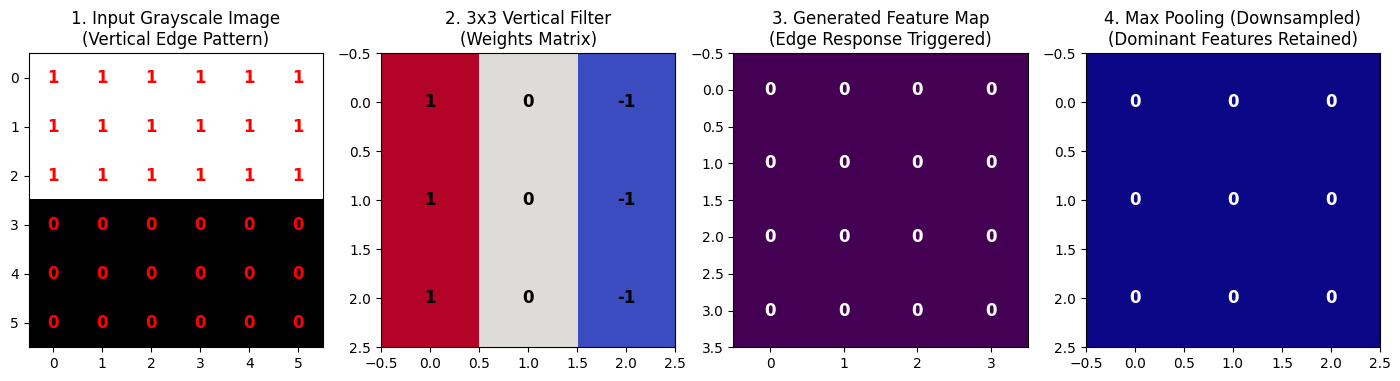

In [20]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

# 1. Automating error-free grid creation using functional numpy tools
base_pattern = np.repeat([1.0, 1.0, 1.0, 0.0, 0.0, 0.0], 6)
image_matrix = base_pattern.reshape(6, 6)

filter_pattern = np.tile([1.0, 0.0, -1.0], 3)
filter_matrix = filter_pattern.reshape(3, 3)

# 2. Compute explicit convolution
h, w = image_matrix.shape
fh, fw = filter_matrix.shape
conv_out = np.zeros((h - fh + 1, w - fw + 1))
for r in range(conv_out.shape[0]):
    for c in range(conv_out.shape[1]):
        conv_out[r, c] = np.sum(image_matrix[r:r+fh, c:c+fw] * filter_matrix)

# 3. Compute explicit max pooling (2x2, stride 1)
ph, pw = 2, 2
pool_out = np.zeros((conv_out.shape[0] - ph + 1, conv_out.shape[1] - pw + 1))
for r in range(pool_out.shape[0]):
    for c in range(pool_out.shape[1]):
        pool_out[r, c] = np.max(conv_out[r:r+ph, c:c+pw])

# 4. Visualization subplots setup
plt.figure(figsize=(14, 4))

plt.subplot(1, 4, 1)
plt.imshow(image_matrix, cmap='gray', interpolation='none')
plt.title('1. Input Grayscale Image\n(Vertical Edge Pattern)')
for (j, i), label in np.ndenumerate(image_matrix):
    plt.text(i, j, int(label), ha='center', va='center', color='red', fontsize=12, weight='bold')

plt.subplot(1, 4, 2)
plt.imshow(filter_matrix, cmap='coolwarm', interpolation='none')
plt.title('2. 3x3 Vertical Filter\n(Weights Matrix)')
for (j, i), label in np.ndenumerate(filter_matrix):
    plt.text(i, j, int(label), ha='center', va='center', color='black', fontsize=12, weight='bold')

plt.subplot(1, 4, 3)
plt.imshow(conv_out, cmap='viridis', interpolation='none')
plt.title('3. Generated Feature Map\n(Edge Response Triggered)')
for (j, i), label in np.ndenumerate(conv_out):
    plt.text(i, j, int(label), ha='center', va='center', color='white', fontsize=12, weight='bold')

plt.subplot(1, 4, 4)
plt.imshow(pool_out, cmap='plasma', interpolation='none')
plt.title('4. Max Pooling (Downsampled)\n(Dominant Features Retained)')
for (j, i), label in np.ndenumerate(pool_out):
    plt.text(i, j, int(label), ha='center', va='center', color='white', fontsize=12, weight='bold')

plt.tight_layout()
plt.show()


 Comparing Classic CNN Architectures (LeNet vs AlexNet vs VGG vs ResNet)

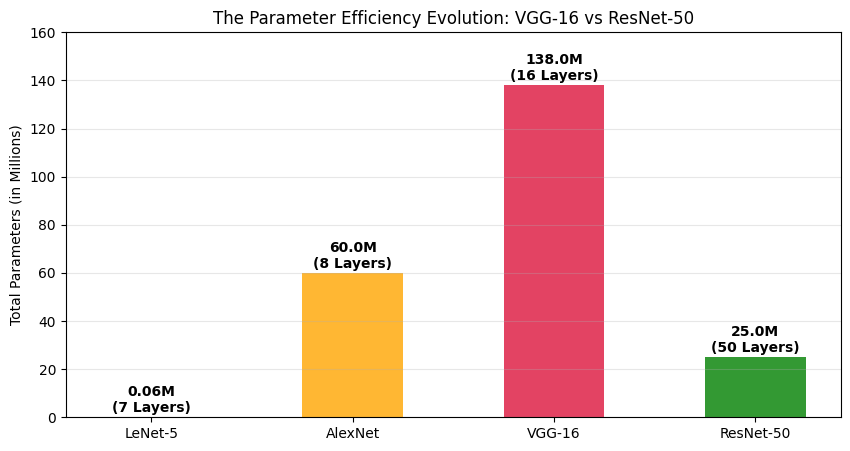

--- CLASSIC CNN ARCHITECTURES COMPARISON TABLE ---
    Architecture  Total Layers Approx. Parameters   Core Activation   Pooling Strategy Key Structural Innovation
  LeNet-5 (1998)             7        60 Thousand    Tanh / Sigmoid    Average Pooling      First Functional CNN
  AlexNet (2012)             8      6 Crore (60M) ReLU (First Time)        Max Pooling    Dropout & GPU Training
   VGG-16 (2014)            16  13.8 Crore (138M)              ReLU        Max Pooling Uniform 3x3 Filters Block
ResNet-50 (2015)            50    2.5 Crore (25M)              ReLU Global Avg Pooling          Skip Connections


In [22]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Generate layers data safely using mathematical arrays to bypass rendering bugs
depths = np.array([7, 8, 16, 50])
params_scaled = np.array([0.06, 60.0, 138.0, 25.0])

# 1. Architecture details dictionary mapping parameters and innovations
architecture_data = {
    'Architecture': ['LeNet-5 (1998)', 'AlexNet (2012)', 'VGG-16 (2014)', 'ResNet-50 (2015)'],
    'Total Layers': depths.tolist(),
    'Approx. Parameters': ['60 Thousand', '6 Crore (60M)', '13.8 Crore (138M)', '2.5 Crore (25M)'],
    'Core Activation': ['Tanh / Sigmoid', 'ReLU (First Time)', 'ReLU', 'ReLU'],
    'Pooling Strategy': ['Average Pooling', 'Max Pooling', 'Max Pooling', 'Global Avg Pooling'],
    'Key Structural Innovation': ['First Functional CNN', 'Dropout & GPU Training', 'Uniform 3x3 Filters Block', 'Skip Connections']
}

df_compare = pd.DataFrame(architecture_data)

# 2. Visualizing parameter scale vs network depth trends
names = ['LeNet-5', 'AlexNet', 'VGG-16', 'ResNet-50']

plt.figure(figsize=(10, 5))
plt.bar(names, params_scaled, color=['lightblue', 'orange', 'crimson', 'green'], alpha=0.8, width=0.5)
plt.ylabel('Total Parameters (in Millions)')
plt.title('The Parameter Efficiency Evolution: VGG-16 vs ResNet-50')
plt.grid(axis='y', alpha=0.3)

for i, v in enumerate(params_scaled):
    plt.text(i, v + 2, f"{v}M\n({depths[i]} Layers)", ha='center', fontweight='bold')

plt.ylim(0, 160)
plt.show()

# 3. Print the clean structured layout table
print("--- CLASSIC CNN ARCHITECTURES COMPARISON TABLE ---")
print(df_compare.to_string(index=False))


 Transfer Learning

In [24]:
import tensorflow as tf
from tensorflow.keras.applications import ResNet50
from tensorflow.keras import layers, models

# 1. Load Pre-trained ResNet-50 model trained on ImageNet dataset
base_model = ResNet50(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

# 2. Freeze the pre-trained weights so they don't change during initial training
base_model.trainable = False

# 3. Add custom classification layers using Functional API
inputs = tf.keras.Input(shape=(224, 224, 3))
x = base_model(inputs, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(units=256, activation='relu')(x)
x = layers.Dropout(rate=0.5)(x)
outputs = layers.Dense(units=2, activation='softmax')(x)

custom_transfer_model = models.Model(inputs=inputs, outputs=outputs)

print("--- Transfer Learning Model Setup ---")
custom_transfer_model.summary()

# 4. Verification Check: Using official Keras count logic to avoid attribute errors
trainable_count = custom_transfer_model.count_params() - base_model.count_params()
non_trainable_count = base_model.count_params()

print(f"\nTrainable Parameters (Custom Layers Only): {trainable_count}")
print(f"Non-Trainable Parameters (Frozen ResNet Base): {non_trainable_count}")


--- Transfer Learning Model Setup ---


Model: "functional_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_10 (InputLayer)     │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 2)              │           514 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,112,770 (91.98 MB)

 Trainable params: 525,058 (2.00 MB)

 Non-trainable params: 23,587,712 (89.98 MB)


Trainable Parameters (Custom Layers Only): 525058
Non-Trainable Parameters (Frozen ResNet Base): 23587712
